# Least Cost Optimization

In [2]:
import pypsa
import matplotlib.pyplot as plt 



In [3]:
plt.style.use("bmh")
%matplotlib inline

In [4]:
n = pypsa.Network("/data/PyPSA-GH/results/networks/elec_s_10_ec_lcopt_Co2L-3h.nc")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


/home/kduah/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


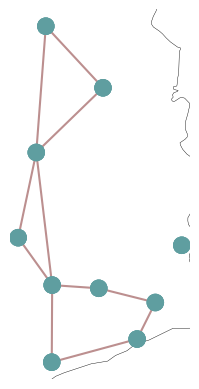

In [5]:
n.plot();

In [6]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component ' {}' has {} entries".format(c.name,len(c.df)))

Component ' Bus' has 30 entries
Component ' Carrier' has 23 entries
Component ' GlobalConstraint' has 1 entries
Component ' Line' has 11 entries
Component ' LineType' has 35 entries
Component ' TransformerType' has 14 entries
Component ' Link' has 40 entries
Component ' Load' has 10 entries
Component ' Generator' has 60 entries
Component ' StorageUnit' has 2 entries
Component ' Store' has 20 entries


Temporal Resolution

In [7]:
n.snapshots[:10]

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)

Static Components Data

In [8]:
n.lines.head()

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,carrier,type,s_max_pu,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,0.211842,380.0,GH0 0,GH0 6,130.373577,False,"MULTILINESTRING ((-0.77544 6.560476200000019, ...",AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,0.317763,380.0,GH0 0,GH0 8,104.368924,False,MULTILINESTRING ((-1.519201800000011 6.6950344...,AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
10,0.651316,380.0,GH0 7,GH0 8,300.292018,False,"MULTILINESTRING ((-1.7055148 8.0862693, -1.705...",AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
2,0.757237,380.0,GH0 1,GH0 5,187.630919,False,"MULTILINESTRING ((-0.8703 10.7945, -0.8703001 ...",AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
3,0.105921,380.0,GH0 1,GH0 7,207.561282,False,MULTILINESTRING ((-1.4500452 8.780951600000016...,AC,Al/St 240/40 4-bundle 380.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [9]:
n.generators.head()

,carrier,bus,p_nom,p_nom_extendable,p_nom_min,p_nom_max,efficiency,marginal_cost,capital_cost,build_year,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
GH0 0 onwind,onwind,GH0 0,0.000899,True,0.0,36109.502135,1.0,0.024920,109295.569252,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 0 solar,solar,GH0 0,4.000000,True,4.0,6838.855138,1.0,0.020793,50855.958267,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 1 onwind,onwind,GH0 1,0.001348,True,0.0,113349.203778,1.0,0.024380,109295.569252,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 1 solar,solar,GH0 1,100.000000,True,100.0,167891.482977,1.0,0.019412,50855.958267,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 2 CCGT,CCGT,GH0 2,1765.000000,False,1765.0,1765.000000,0.5,47.210034,84469.122809,2010,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [10]:
n.storage_units.head()

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,build_year,lifetime,...,spill_cost,marginal_cost_quadratic,marginal_cost_storage,capital_cost,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH0 6 hydro,hydro,GH0 6,1180.0,35430.799776,0.0,0.9,0.0,True,1971,119.0,...,0.0,0.0,0.0,0.0,0.0,False,NaN,True,0.0,0.0
GH0 7 hydro,hydro,GH0 7,404.0,35430.799776,0.0,0.9,0.0,True,2013,100.0,...,0.0,0.0,0.0,0.0,0.0,False,NaN,True,0.0,0.0


In [11]:
n.loads.head()

,bus,carrier,type,p_set,q_set,sign
Load,,,,,,
GH0 0,GH0 0,,,0.0,0.0,-1.0
GH0 1,GH0 1,,,0.0,0.0,-1.0
GH0 2,GH0 2,,,0.0,0.0,-1.0
GH0 3,GH0 3,,,0.0,0.0,-1.0
GH0 4,GH0 4,,,0.0,0.0,-1.0


In [12]:
# The above is because it is mostly time dependent data

In [13]:
n.loads_t.p_set.head()

Load,GH0 0,GH0 1,GH0 2,GH0 3,GH0 4,GH0 5,GH0 6,GH0 7,GH0 8,GH1 0
snapshot,,,,,,,,,,
2013-01-01 00:00:00,205.418620,145.539863,178.172802,299.231996,139.874570,130.659038,135.397452,92.277556,224.404764,135.691604
2013-01-01 03:00:00,221.422053,156.878355,192.053610,322.544095,150.771699,140.838218,145.945785,99.466571,241.887340,146.262853
2013-01-01 06:00:00,267.007031,189.175483,231.592398,388.947442,181.811627,169.833104,175.992184,119.944123,291.685582,176.374528
2013-01-01 09:00:00,318.042723,225.334462,275.858941,463.290810,216.563080,202.294983,209.631309,142.870228,347.438329,210.086735
2013-01-01 12:00:00,328.285053,232.591191,284.742774,478.210746,223.537333,208.809743,216.382330,147.471257,358.627323,216.852422


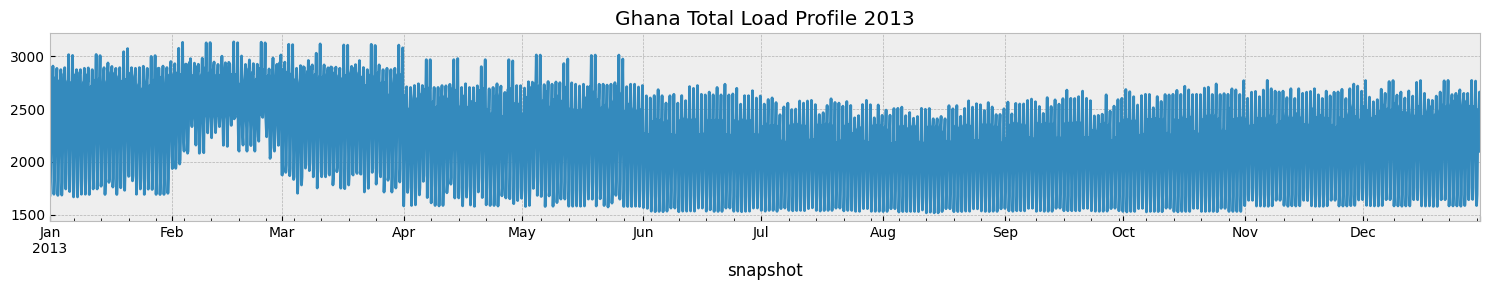

In [42]:
ax = n.loads_t.p_set.sum(axis=1).plot(figsize=(15,3), title="Ghana Total Load Profile 2013")
plt.tight_layout()
plt.savefig("01_load_profile.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
n.generators_t.p_max_pu.head()

Generator,GH0 0 onwind,GH0 0 solar,GH0 1 onwind,GH0 1 solar,GH0 2 offwind-ac,GH0 2 offwind-dc,GH0 2 onwind,GH0 2 solar,GH0 3 offwind-ac,GH0 3 offwind-dc,...,GH0 6 offwind-ac,GH0 6 offwind-dc,GH0 6 onwind,GH0 6 solar,GH0 7 onwind,GH0 7 solar,GH0 8 onwind,GH0 8 solar,GH1 0 onwind,GH1 0 solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.063594,0.000000,0.395475,0.000000,0.013537,0.027683,0.0,0.000000,0.000000,0.024724,...,0.030447,0.059697,0.000000,0.000000,0.264197,0.000000,0.120534,0.000000,0.157327,0.000000
2013-01-01 03:00:00,0.035099,0.000000,0.312775,0.000000,0.000000,0.000000,0.0,0.000000,0.023377,0.031912,...,0.021885,0.039555,0.000000,0.000000,0.252713,0.000000,0.103675,0.000000,0.111123,0.000000
2013-01-01 06:00:00,0.036801,0.058155,0.255908,0.058238,0.000000,0.010366,0.0,0.038168,0.022690,0.000000,...,0.096920,0.025425,0.016017,0.062621,0.188389,0.052025,0.091834,0.053775,0.064612,0.063112
2013-01-01 09:00:00,0.016167,0.439417,0.225586,0.439766,0.000000,0.000000,0.0,0.392616,0.034707,0.019474,...,0.137475,0.063990,0.060251,0.435021,0.131861,0.432443,0.064823,0.435562,0.019712,0.443399
2013-01-01 12:00:00,0.000000,0.574146,0.091541,0.576501,0.000000,0.000000,0.0,0.526405,0.033957,0.000000,...,0.049681,0.026330,0.018654,0.566457,0.058057,0.578439,0.028253,0.578709,0.000000,0.573005


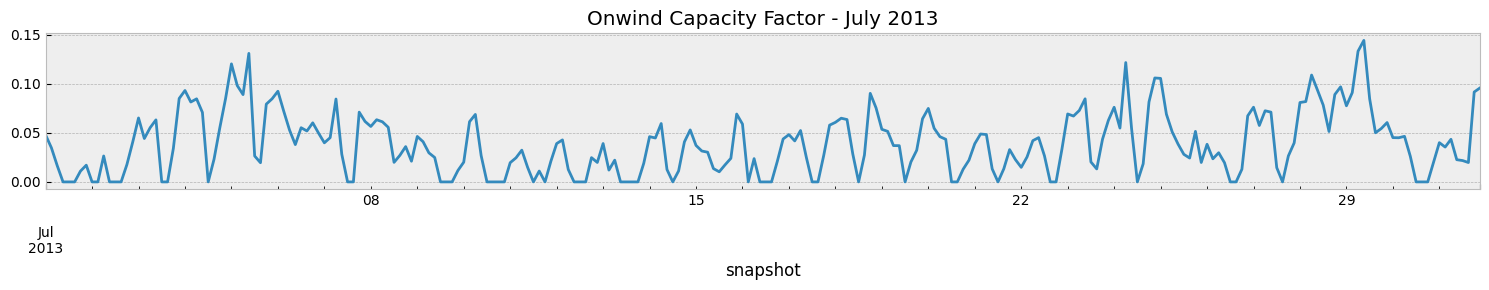

In [43]:
ax = n.generators_t.p_max_pu.loc["2013-07", "GH0 0 onwind"].plot(figsize=(15,3), title="Onwind Capacity Factor - July 2013")
plt.tight_layout()
plt.savefig("02_wind_capacity_factor.png", dpi=150, bbox_inches='tight')
plt.show()

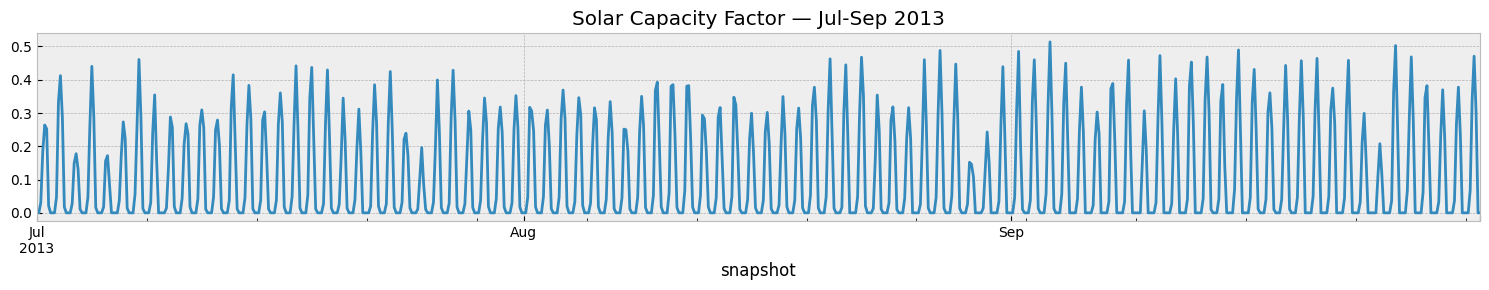

In [44]:
ax = n.generators_t.p_max_pu.loc["2013-07":"2013-09", "GH0 0 solar"].plot(figsize=(15,3), title="Solar Capacity Factor — Jul-Sep 2013")
plt.tight_layout()
plt.savefig("03_solar_capacity_factor.png", dpi=150, bbox_inches='tight')
plt.show()

TOTAL ANNUAL SYSTEM COSTS

In [18]:
n.objective / 1e9 #billion euros

np.float64(0.5602839729469441)

In [19]:
(n.lines.s_nom_opt - n.lines.s_nom).head(5)

Line
0     1.463391e+02
1     0.000000e+00
10    2.273737e-13
2     2.273737e-13
3     2.199673e+02
dtype: float64

Optimal Generator Storage Capacities

In [20]:
n.generators.groupby("carrier").p_nom_opt.sum() / 1e3

carrier
CCGT             3.582155
load shedding    3.761590
offwind-ac       0.000000
offwind-dc       0.000000
oil              0.879485
onwind           0.000000
solar            6.399496
Name: p_nom_opt, dtype: float64

In [21]:
n.storage_units.groupby("carrier").p_nom_opt.sum() / 1e3

carrier
hydro    1.584
Name: p_nom_opt, dtype: float64

Energy Storage

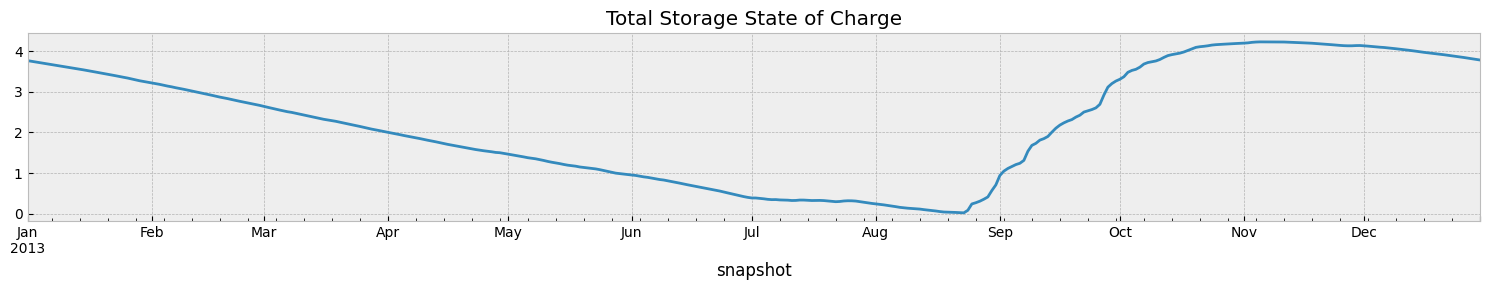

In [45]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample('D').mean() / 1e6).plot(figsize=(15, 3), title="Total Storage State of Charge")
plt.tight_layout()
plt.savefig("04_total_storage_soc.png", dpi=150, bbox_inches='tight')
plt.show()

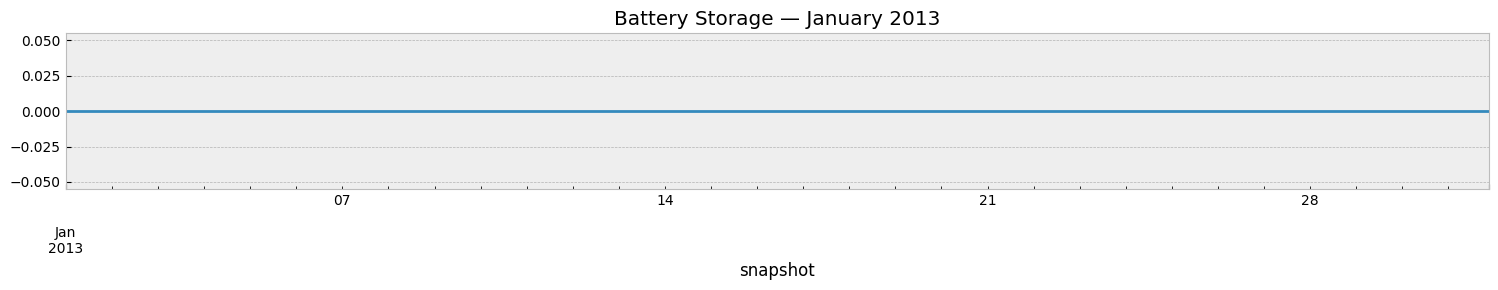

In [46]:
(n.storage_units_t.state_of_charge.loc["2013-01"].filter(like="battery", axis=1).sum(axis=1) / 1e6).plot(figsize=(15, 3), title="Battery Storage — January 2013")
plt.tight_layout()
plt.savefig("05_battery_soc.png", dpi=150, bbox_inches='tight')
plt.show()

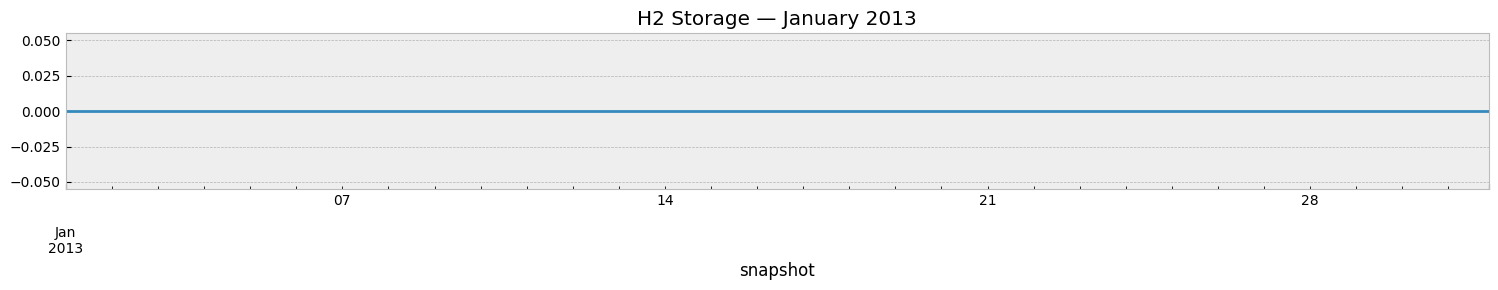

In [47]:
(n.storage_units_t.state_of_charge.loc["2013-01"].filter(like="H2", axis=1).sum(axis=1) / 1e6).plot(figsize=(15, 3), title="H2 Storage — January 2013")
plt.tight_layout()
plt.savefig("06_h2_soc.png", dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# ... your map code ...
plt.savefig("07_network_loading_map.png", dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
import cartopy.crs as ccrs

In [26]:
loading =  (n.lines_t.p0.abs().mean().sort_index() / (n.lines.s_nom_opt*n.lines.s_max_pu).sort_index().fillna(0.))

/home/kduah/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


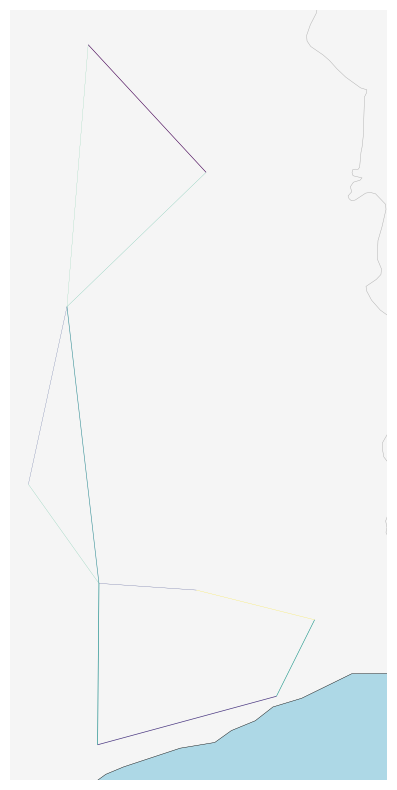

In [27]:
fig, ax = plt.subplots(
        figsize= (10, 10),
        subplot_kw={"projection": ccrs.Orthographic()})


n.plot(ax=ax,
       bus_colors='gray',
       branch_components=["Line"],
       line_widths=n.lines.s_nom_opt/3e3,
       line_colors=loading,
       line_cmap=plt.cm.viridis,
       color_geomap=True,
       bus_sizes=0)
ax.axis("off");

/home/kduah/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


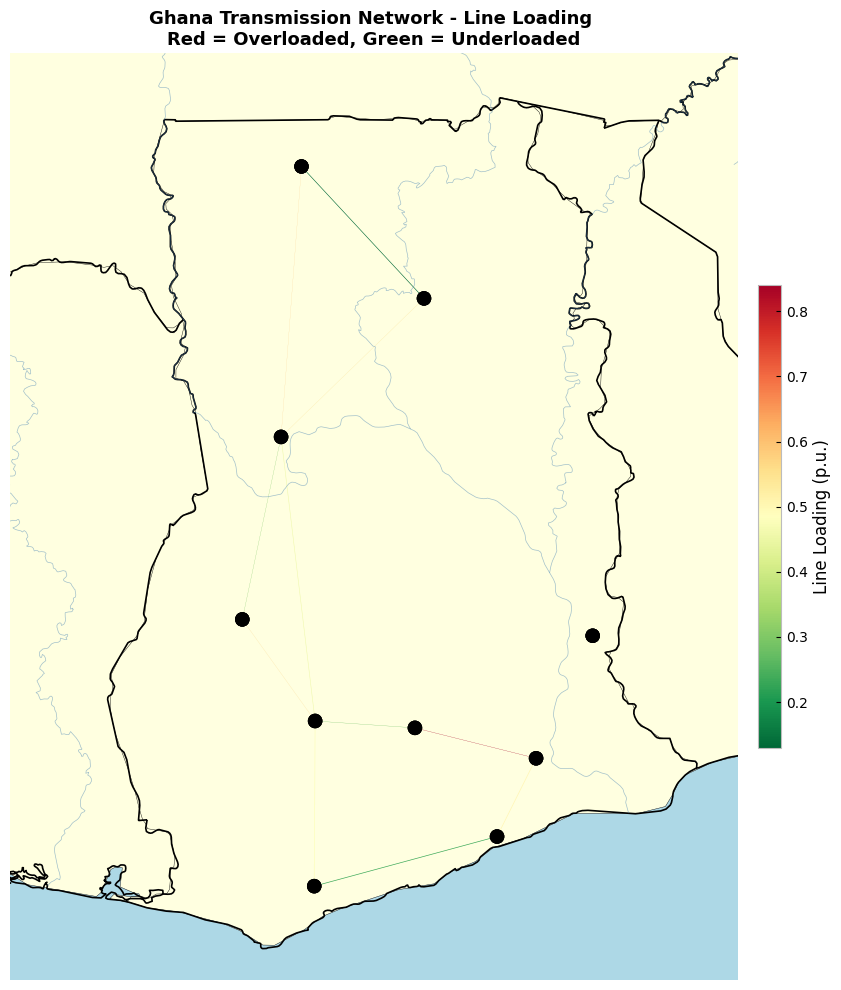

In [50]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

loading = (n.lines_t.p0.abs().mean().sort_index() / 
           (n.lines.s_nom_opt * n.lines.s_max_pu).sort_index().fillna(0.))

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()})

# Plot network FIRST with color_geomap=False style
n.plot(
    ax=ax,
    bus_colors='black',
    branch_components=["Line"],
    line_widths=n.lines.s_nom_opt / 3e3,
    line_colors=loading,
    line_cmap=plt.cm.RdYlGn_r,
    color_geomap={"ocean": "lightblue", "land": "lightyellow"},
    bus_sizes=0.003,
)

# Add features ON TOP with high zorder
ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='black', zorder=5)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=5)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='steelblue', alpha=0.5, zorder=5)

# Zoom to Ghana
ax.set_extent([-4.0, 1.5, 4.5, 11.5], crs=ccrs.PlateCarree())

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.RdYlGn_r,
    norm=mcolors.Normalize(vmin=loading.min(), vmax=loading.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label('Line Loading (p.u.)', fontsize=12)

ax.set_title("Ghana Transmission Network - Line Loading \nRed = Overloaded, Green = Underloaded",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("08-Ghana-transmission lines")
plt.show()

<Axes: title={'center': 'Optimal Installed Capacity by Technology (GW)'}, xlabel='carrier'>

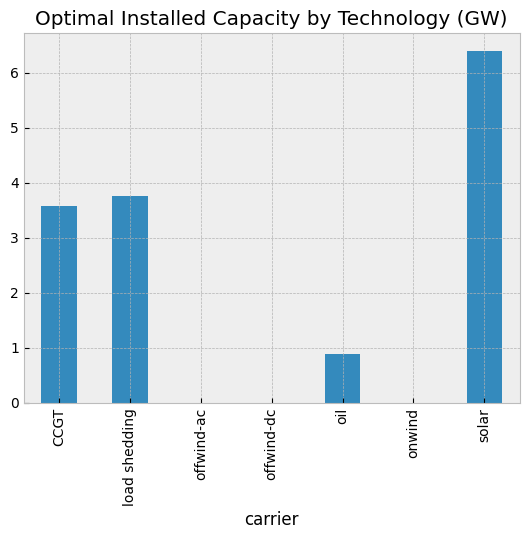

In [31]:
# What did the optimizer actually decide to build and dispatch?
n.generators.groupby("carrier").p_nom_opt.sum().div(1e3).plot.bar(
    title="Optimal Installed Capacity by Technology (GW)")

In [32]:
# How much did each technology actually generate?
n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().sum() / 1e6
# TWh per carrier

/tmp/ipykernel_89630/2568051513.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().sum() / 1e6


carrier
CCGT             1.344391
load shedding    0.000000
offwind-ac       0.000000
offwind-dc       0.000000
oil              0.000000
onwind           0.000000
solar            2.638138
dtype: float64

/tmp/ipykernel_89630/2142965281.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  gen = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()


<Axes: title={'center': 'Dispatch Stack — July 2013 (Dry Season)'}, xlabel='snapshot'>

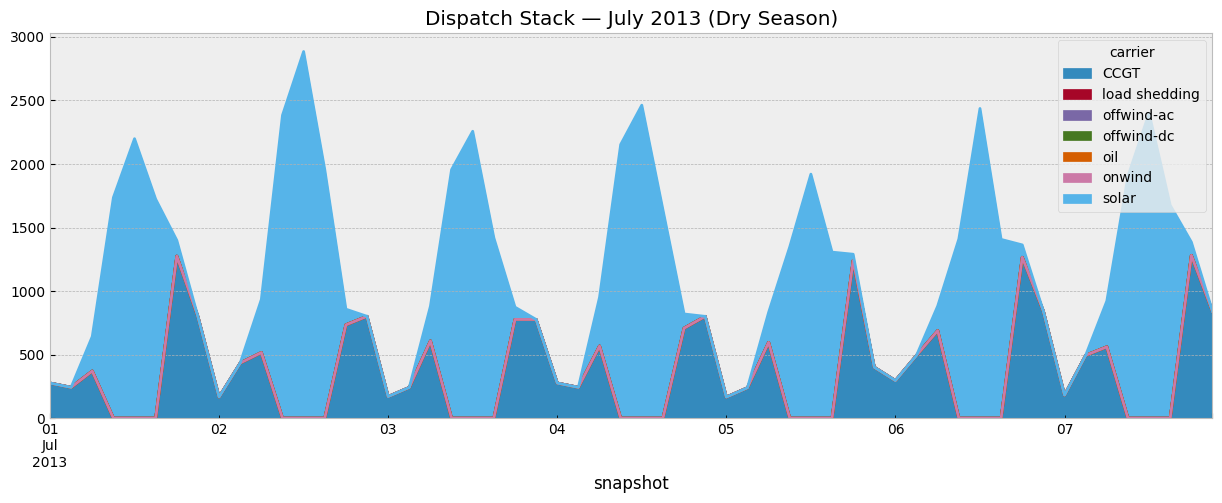

In [33]:
# One week dispatch showing how technologies work together
gen = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum()
gen.loc["2013-07-01":"2013-07-07"].plot.area(
    figsize=(15,5), title="Dispatch Stack — July 2013 (Dry Season)")

<Axes: title={'center': 'Solar Weekly Output'}, xlabel='snapshot'>

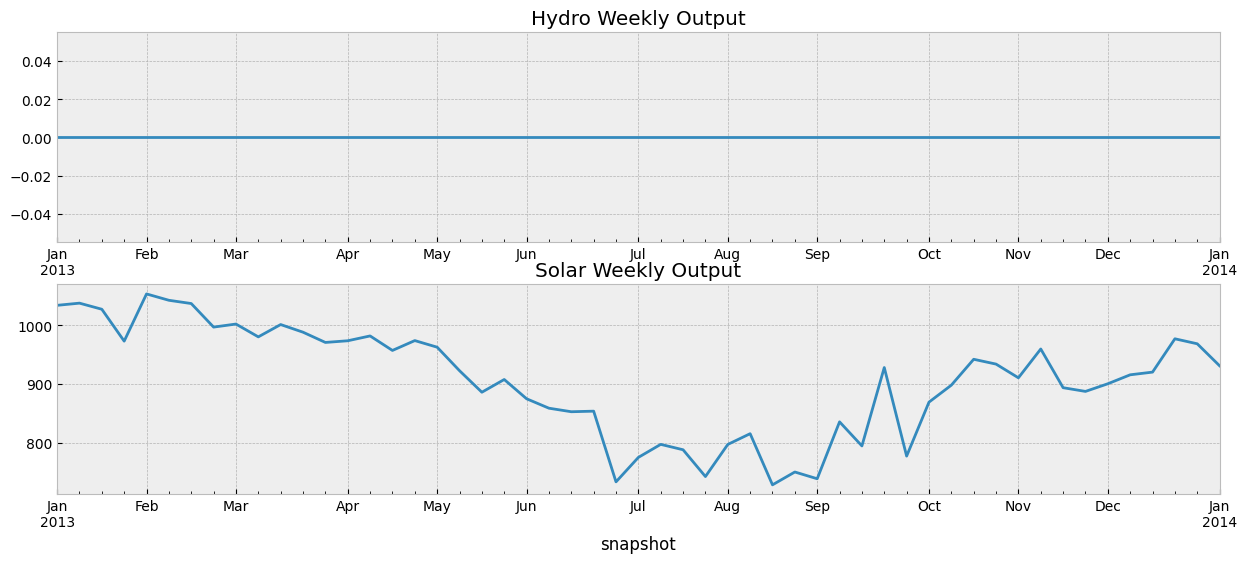

In [34]:
# Shows Ghana's hydro-solar complementarity — key insight
fig, axes = plt.subplots(2, 1, figsize=(15, 6))
n.generators_t.p.filter(like="hydro").resample("W").mean().sum(axis=1).plot(ax=axes[0], title="Hydro Weekly Output")
n.generators_t.p.filter(like="solar").resample("W").mean().sum(axis=1).plot(ax=axes[1], title="Solar Weekly Output")

Total CO2 emissions: 0.50 Mt CO2


/tmp/ipykernel_89630/265676705.py:7: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(n.generators.carrier, axis=1).sum()  # group by carrier
/tmp/ipykernel_89630/265676705.py:17: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(n.generators.carrier, axis=1).sum()


<Axes: title={'center': 'CO2 Emissions by Carrier (Mt CO2)'}>

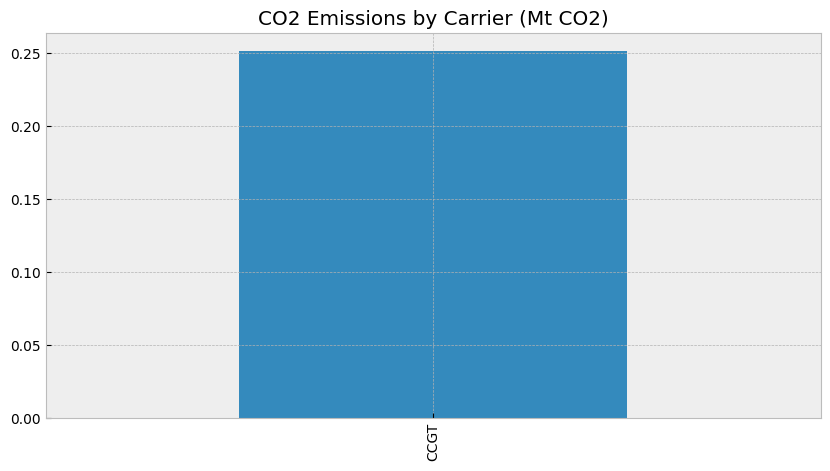

In [37]:
# Map co2_emissions from carriers to generators
co2_per_carrier = n.carriers.co2_emissions  # tCO2/MWh_thermal

# Calculate emissions
emissions = (
    n.generators_t.p  # MWh dispatch
    .groupby(n.generators.carrier, axis=1).sum()  # group by carrier
    .multiply(co2_per_carrier / n.generators.groupby("carrier").efficiency.mean(), axis=1)  # tCO2
    .sum().sum()  # total
)

print(f"Total CO2 emissions: {emissions/1e6:.2f} Mt CO2")

# By carrier
emissions_by_carrier = (
    n.generators_t.p
    .groupby(n.generators.carrier, axis=1).sum()
    .multiply(co2_per_carrier, axis=1)
    .sum() / 1e6
)
emissions_by_carrier[emissions_by_carrier > 0].plot.bar(
    title="CO2 Emissions by Carrier (Mt CO2)", 
    figsize=(10, 5))

In [38]:
# How much renewable energy was wasted?
curtailment = n.generators_t.p_max_pu * n.generators.p_nom_opt - n.generators_t.p

In [39]:
# Where does the money go?
capex = n.generators.p_nom_opt * n.generators.capital_cost
opex = n.generators_t.p.sum() * n.generators.marginal_cost

<Axes: title={'center': 'Capacity Factors'}, xlabel='carrier'>

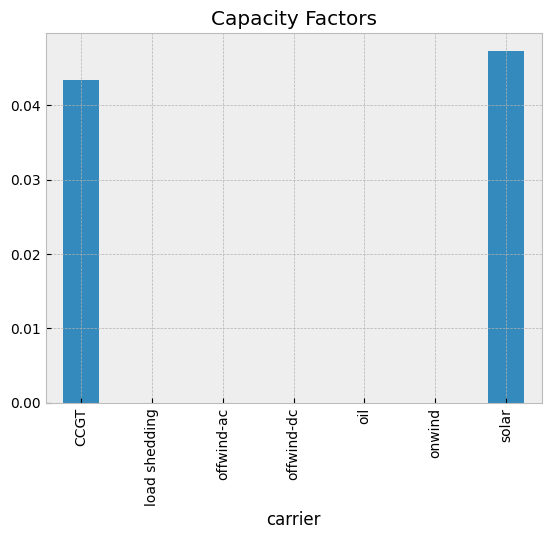

In [ ]:
cf = n.generators_t.p.sum() / (n.generators.p_nom_opt * 8760)
cf.groupby(n.generators.carrier).mean().plot.bar(title="Capacity Factors")


In [51]:
print(f"Cost EUR: {n.objective/1e9:.2f} B EUR")
print(f"Cost GHS: {n.objective * 12.5 / 1e9:.2f} B GHS")  # approximate rate
print(n.generators.groupby("carrier").p_nom_opt.sum() / 1e3)
print(n.storage_units.groupby("carrier").p_nom_opt.sum() / 1e3)

Cost EUR: 0.56 B EUR
Cost GHS: 7.00 B GHS
carrier
CCGT             3.582155
load shedding    3.761590
offwind-ac       0.000000
offwind-dc       0.000000
oil              0.879485
onwind           0.000000
solar            6.399496
Name: p_nom_opt, dtype: float64
carrier
hydro    1.584
Name: p_nom_opt, dtype: float64
